# Word2Vec – Przykłady użycia modelu

Notebook zakłada, że masz już wytrenowany model z `word2vec_tutorial.ipynb`.  
Jeśli nie – uruchom najpierw tamten notebook i wróć tutaj.

In [2]:
from gensim.models import Word2Vec
import numpy as np

model = Word2Vec.load("wolne_lektury_w2v.model")
wv = model.wv

print(f"Model załadowany: {len(wv):,} słów, wektory {wv.vector_size}D")

Model załadowany: 257,917 słów, wektory 100D


---
## 1. Eksploracja słownika

In [3]:
# Najczęstsze słowa w słowniku
# wv.index_to_key – lista słów posortowana od najczęstszych
print("Top 30 najczęstszych słów:")
print(wv.index_to_key[:30])

Top 30 najczęstszych słów:
['i', 'się', 'w', 'nie', 'na', 'z', 'do', 'to', 'że', 'a', 'o', 'jak', 'co', 'tak', 'jest', 'ale', 'po', 'za', 'od', 'już', 'mnie', 'go', 'jego', 'jej', 'mi', 'tylko', 'tym', 'mu', 'tego', 'dla']


In [4]:
# Sprawdzanie czy słowo jest w słowniku
slowa = ["miłość", "python", "król", "smartphone", "rycerz", "komputer"]

for s in slowa:
    status = "✓ jest" if s in wv else "✗ brak"
    print(f"  {status}  '{s}'")

  ✓ jest  'miłość'
  ✗ brak  'python'
  ✓ jest  'król'
  ✗ brak  'smartphone'
  ✓ jest  'rycerz'
  ✓ jest  'komputer'


---
## 2. Podobieństwo między słowami

Model zwraca liczbę od -1 do 1 (podobieństwo cosinusowe).

In [5]:
# Pary słów i ich podobieństwo
pary = [
    ("ojciec",  "matka"),
    ("ojciec",  "syn"),
    ("ojciec",  "rzeka"),
    ("król",    "władca"),
    ("miłość",  "nienawiść"),
    ("miłość",  "czułość"),
    ("bitwa",   "pokój"),
    ("miecz",   "pióro"),
]

print(f"{'Para':35} {'Podobieństwo':>12}  Wizualizacja")
print("-" * 70)
for w1, w2 in pary:
    if w1 in wv and w2 in wv:
        s = wv.similarity(w1, w2)
        bar_len = int((s + 1) / 2 * 25)  # skaluj -1..1 → 0..25
        bar = "█" * bar_len + "░" * (25 - bar_len)
        print(f"  {w1} ↔ {w2:25} {s:>8.4f}  [{bar}]")

Para                                Podobieństwo  Wizualizacja
----------------------------------------------------------------------
  ojciec ↔ matka                       0.6877  [█████████████████████░░░░]
  ojciec ↔ syn                         0.8070  [██████████████████████░░░]
  ojciec ↔ rzeka                       0.2630  [███████████████░░░░░░░░░░]
  król ↔ władca                      0.7402  [█████████████████████░░░░]
  miłość ↔ nienawiść                   0.7835  [██████████████████████░░░]
  miłość ↔ czułość                     0.7973  [██████████████████████░░░]
  bitwa ↔ pokój                       0.2029  [███████████████░░░░░░░░░░]
  miecz ↔ pióro                       0.4866  [██████████████████░░░░░░░]


---
## 3. Najbliżsi sąsiedzi

In [6]:
# Dla dowolnego słowa – znajdź 10 najbardziej podobnych
def sasiedzi(slowo, n=10):
    if slowo not in wv:
        print(f"'{slowo}' nie ma w słowniku")
        return
    wyniki = wv.most_similar(slowo, topn=n)
    print(f"\nNajbliższe słowa do '{slowo}':")
    for i, (w, s) in enumerate(wyniki, 1):
        print(f"  {i:2}. {w:20} {s:.4f}")

sasiedzi("bóg")
sasiedzi("serce")
sasiedzi("śmierć")


Najbliższe słowa do 'bóg':
   1. wszechmogący         0.8347
   2. stwórca              0.8024
   3. chrystus             0.7826
   4. przedwieczny         0.7779
   5. nierychliwy          0.7642
   6. wszechmocny          0.7622
   7. miłosierny           0.7589
   8. najwyszejszy         0.7549
   9. jezus                0.7544
  10. allach               0.7502

Najbliższe słowa do 'serce':
   1. serduszko            0.7897
   2. rozrania             0.7062
   3. sumienie             0.7057
   4. zabiło               0.6974
   5. uczucie              0.6950
   6. zmiękło              0.6943
   7. pierś                0.6921
   8. pulsa                0.6919
   9. rozjątrza            0.6894
  10. zakrwawiło           0.6848

Najbliższe słowa do 'śmierć':
   1. kaźń                 0.7108
   2. zgubę                0.7091
   3. zagładę              0.7074
   4. zgon                 0.7009
   5. głodowa              0.6944
   6. rychła               0.6840
   7. niesławną            

---
## 4. Analogie – arytmetyka na wektorach

`positive` = słowa, które **dodajemy**  
`negative` = słowa, które **odejmujemy**

In [7]:
def analogia(positive, negative, n=5):
    brak = [w for w in positive + negative if w not in wv]
    if brak:
        print(f"Brak w słowniku: {brak}")
        return
    wyniki = wv.most_similar(positive=positive, negative=negative, topn=n)
    plus  = " + ".join(positive)
    minus = " - ".join(negative)
    print(f"{plus} - {minus} = ?")
    for w, s in wyniki:
        print(f"  → {w:20} ({s:.4f})")
    print()

# Hierarchia władzy i płeć
analogia(["król",    "kobieta"],  ["mężczyzna"])
analogia(["książę",  "kobieta"],  ["mężczyzna"])

# Czas dnia
analogia(["noc",    "słońce"],   ["księżyc"])

# Relacje rodzinne
analogia(["ojciec", "córka"],    ["syn"])

# Natura
analogia(["morze",  "rzeka"],    ["ocean"])

król + kobieta - mężczyzna = ?
  → królowa              (0.8524)
  → królewna             (0.7726)
  → cesarzowa            (0.7623)
  → księżniczka          (0.7578)
  → księżna              (0.7201)

książę + kobieta - mężczyzna = ?
  → księżna              (0.8219)
  → królowa              (0.7916)
  → księżniczka          (0.7726)
  → matylda              (0.7324)
  → hrabina              (0.7249)

noc + słońce - księżyc = ?
  → nockę                (0.6733)
  → zima                 (0.6659)
  → jesień               (0.6515)
  → lato                 (0.6467)
  → bezsenną             (0.6430)

ojciec + córka - syn = ?
  → matka                (0.8888)
  → żona                 (0.8301)
  → siostra              (0.8257)
  → ciotka               (0.8216)
  → babka                (0.8187)

morze + rzeka - ocean = ?
  → wisła                (0.7495)
  → jezioro              (0.7202)
  → woda                 (0.6992)
  → barka                (0.6527)
  → jeziorko             (0.6428)



---
## 5. Znajdź intruza

Które słowo semantycznie **nie pasuje** do reszty?

In [8]:
def intruz(slowa):
    dostepne = [w for w in slowa if w in wv]
    brak = set(slowa) - set(dostepne)
    if brak:
        print(f"  Pominięto (brak): {brak}")
    if len(dostepne) < 3:
        print("  Za mało słów")
        return
    wynik = wv.doesnt_match(dostepne)
    print(f"{dostepne}  →  intruz: '{wynik}'")

intruz(["rzeka", "morze", "jezioro", "staw",  "miecz"])
intruz(["radość", "szczęście", "miłość", "bitwa", "nadzieja"])
intruz(["koń", "pies", "kot", "wilk", "chleb"])
intruz(["król", "cesarz", "hetman", "sułtan", "chłop"])
intruz(["matka", "ojciec", "córka", "syn", "miecz"])

['rzeka', 'morze', 'jezioro', 'staw', 'miecz']  →  intruz: 'miecz'
['radość', 'szczęście', 'miłość', 'bitwa', 'nadzieja']  →  intruz: 'bitwa'
['koń', 'pies', 'kot', 'wilk', 'chleb']  →  intruz: 'chleb'
['król', 'cesarz', 'hetman', 'sułtan', 'chłop']  →  intruz: 'chłop'
['matka', 'ojciec', 'córka', 'syn', 'miecz']  →  intruz: 'miecz'


---
## 6. Podobieństwo zdań (uśrednianie wektorów)

Prosty sposób na reprezentację zdania: **uśrednij wektory słów**.  
Potem można mierzyć podobieństwo między zdaniami.

In [9]:
import re

def zdanie_na_wektor(tekst):
    """Tokenizuje zdanie i zwraca uśredniony wektor słów obecnych w modelu."""
    tokeny = re.sub(r'[^a-ząćęłńóśźż\s]', ' ', tekst.lower()).split()
    wektory = [wv[t] for t in tokeny if t in wv]
    if not wektory:
        return None
    return np.mean(wektory, axis=0)

def podobienstwo_zdan(z1, z2):
    """Podobieństwo cosinusowe dwóch zdań."""
    v1 = zdanie_na_wektor(z1)
    v2 = zdanie_na_wektor(z2)
    if v1 is None or v2 is None:
        return None
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


zdania = [
    "Król zasiadł na tronie i wydał rozkaz.",
    "Władca objął rządy i przemówił do ludu.",
    "Rycerz dobył miecza i ruszył do bitwy.",
    "Wojownik wziął broń i stanął do walki.",
    "Dziewczyna biegła przez łąkę i śpiewała.",
]

print("Podobieństwo między zdaniami (macierz):\n")
print(f"{'':4}", end="")
for i in range(len(zdania)):
    print(f"  Z{i+1}  ", end="")
print()

for i, z1 in enumerate(zdania):
    print(f"Z{i+1} ", end="")
    for z2 in zdania:
        s = podobienstwo_zdan(z1, z2)
        print(f" {s:.3f}", end="")
    print(f"  ← {z1[:45]}..." if len(z1) > 45 else f"  ← {z1}")

Podobieństwo między zdaniami (macierz):

      Z1    Z2    Z3    Z4    Z5  
Z1  1.000 0.766 0.717 0.762 0.446  ← Król zasiadł na tronie i wydał rozkaz.
Z2  0.766 1.000 0.677 0.763 0.476  ← Władca objął rządy i przemówił do ludu.
Z3  0.717 0.677 1.000 0.871 0.489  ← Rycerz dobył miecza i ruszył do bitwy.
Z4  0.762 0.763 0.871 1.000 0.514  ← Wojownik wziął broń i stanął do walki.
Z5  0.446 0.476 0.489 0.514 1.000  ← Dziewczyna biegła przez łąkę i śpiewała.


---
## 7. Klasteryzacja słów (K-Means)

Pogrupuj 200 najczęstszych słów automatycznie – bez podawania nazw grup.

In [10]:
from sklearn.cluster import KMeans

# Weź N najczęstszych słów (pomijając stopwords)
STOPWORDS = {"się", "nie", "to", "że", "i", "w", "z", "na", "do", "jak",
             "go", "jej", "jego", "już", "ale", "bo", "co", "a", "o", "pan",
             "tak", "ten", "ta", "te", "by", "mu", "mi", "też", "po", "czy"}

TOP_N = 300
N_CLUSTERS = 8

slowa_top = [w for w in wv.index_to_key if w not in STOPWORDS][:TOP_N]
wektory = wv[slowa_top]

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
etykiety = kmeans.fit_predict(wektory)

# Pokaż zawartość każdego klastra
for k in range(N_CLUSTERS):
    slowa_k = [slowa_top[i] for i, e in enumerate(etykiety) if e == k]
    print(f"\nKlaster {k+1} ({len(slowa_k)} słów):")
    print("  " + ", ".join(slowa_k[:20]))


Klaster 1 (12 słów):
  jest, było, był, była, być, są, były, jestem, byli, stał, jesteś, stało

Klaster 2 (24 słów):
  niż, więcej, jeden, lat, tyle, kilka, dwa, jakie, wiele, ile, bardziej, coraz, innych, trochę, dni, jednego, trzy, całe, jedno, mniej

Klaster 3 (163 słów):
  za, od, mnie, tylko, tym, tego, dla, przez, gdy, sobie, jeszcze, ze, który, tu, aby, ją, które, tej, pod, przed

Klaster 4 (53 słów):
  ja, on, ci, sam, ty, kto, mój, dobrze, niech, cię, jeśli, nam, człowiek, jeżeli, wszyscy, dziś, ludzie, cóż, wiem, czas

Klaster 5 (7 słów):
  und, the, in, die, der, of, sie

Klaster 6 (13 słów):
  pani, rzekł, pana, de, panie, mówił, powiedział, mówi, panu, proszę, powiedzieć, mówić, rzekła

Klaster 7 (9 słów):
  ich, j, im, wie, was, m, s, da, t

Klaster 8 (19 słów):
  może, ma, będzie, miał, można, trzeba, mógł, mam, miała, chciał, musi, chce, będę, mogę, mają, mieć, masz, zaczął, mogła


---
## 8. Wizualizacja t-SNE klastrów

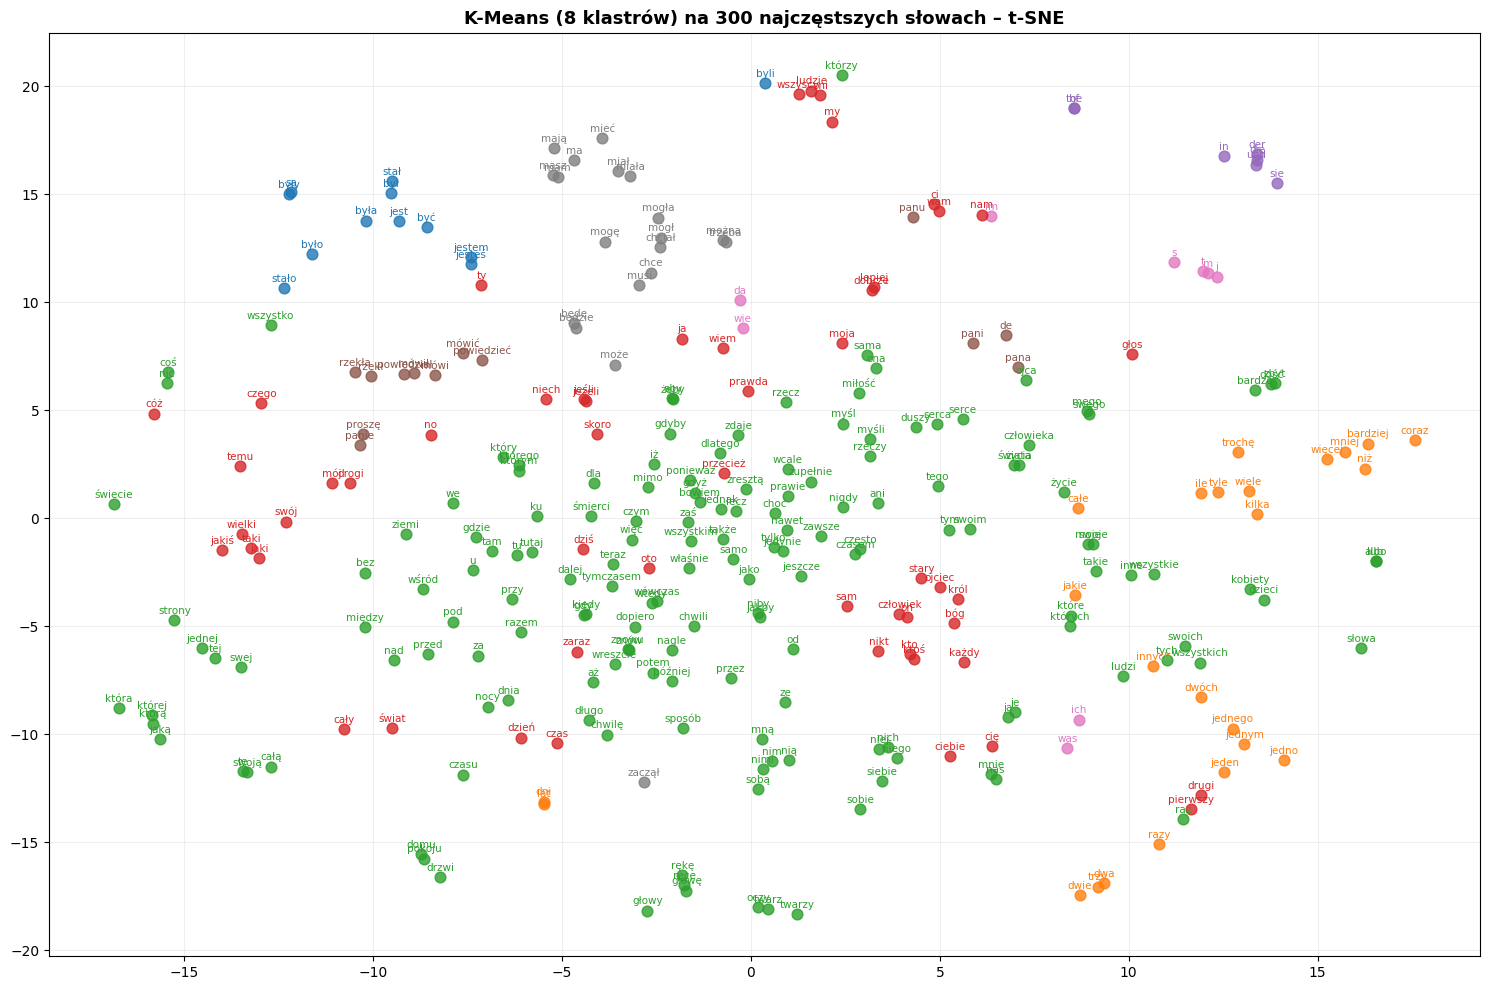

In [11]:
import matplotlib.pyplot as plt
import matplotlib
from sklearn.manifold import TSNE

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Redukuj do 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
pts = tsne.fit_transform(wektory)

kolory = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(15, 10))
for i, (x, y) in enumerate(pts):
    k = etykiety[i]
    ax.scatter(x, y, color=kolory[k % len(kolory)], s=60, zorder=2, alpha=0.8)
    ax.annotate(slowa_top[i], (x, y), fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points', color=kolory[k % len(kolory)])

ax.set_title(f"K-Means ({N_CLUSTERS} klastrów) na {TOP_N} najczęstszych słowach – t-SNE",
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## 9. Wyszukiwanie semantyczne

Podaj zapytanie w naturalnym języku – znajdź najbardziej "pasujące" słowa z modelu.

In [12]:
def szukaj(zapytanie, n=10):
    """
    Traktuje zapytanie jako bag-of-words, uśrednia wektory
    i zwraca n słów z modelu o najwyższym podobieństwie.
    """
    tokeny = re.sub(r'[^a-ząćęłńóśźż\s]', ' ', zapytanie.lower()).split()
    wektory_q = [wv[t] for t in tokeny if t in wv]
    if not wektory_q:
        print("Żadne słowo zapytania nie jest w słowniku")
        return
    q_vec = np.mean(wektory_q, axis=0)
    wyniki = wv.similar_by_vector(q_vec, topn=n + len(tokeny))
    # odfiltruj słowa z zapytania
    wyniki = [(w, s) for w, s in wyniki if w not in tokeny][:n]
    print(f"\nZapytanie: '{zapytanie}'")
    for i, (w, s) in enumerate(wyniki, 1):
        print(f"  {i:2}. {w:20} {s:.4f}")

szukaj("walka i chwała rycerza")
szukaj("miłość i tęsknota")
szukaj("przyroda rzeka las")
szukaj("bóg modlitwa wiara")


Zapytanie: 'walka i chwała rycerza'
   1. rozgłośna            0.7968
   2. gromka               0.7858
   3. bezprzedmiotowa      0.7673
   4. saturninie           0.7626
   5. turbacja             0.7580
   6. odkupiona            0.7503
   7. orężna               0.7469
   8. zamordowało          0.7427
   9. pojednana            0.7421
  10. oszpeciła            0.7410

Zapytanie: 'miłość i tęsknota'
   1. namiętność           0.8291
   2. nostalgia            0.8002
   3. nieukojona           0.7962
   4. tkliwość             0.7955
   5. najtkliwsza          0.7868
   6. niewysłowiona        0.7758
   7. tęsknica             0.7755
   8. egzaltacya           0.7727
   9. beznadzieja          0.7709
  10. katusza              0.7640

Zapytanie: 'przyroda rzeka las'
   1. zatoka               0.7901
   2. płaszczyzna          0.7718
   3. wisła                0.7577
   4. rzeczka              0.7551
   5. dolina               0.7512
   6. grobla               0.7435
   7. creeki  

---
## 10. Interpolacja między słowami

Przejdź płynnie od jednego słowa do drugiego w przestrzeni wektorowej.

In [13]:
def interpoluj(slowo_a, slowo_b, kroki=6):
    """Wyświetl słowa leżące na 'drodze' od słowa A do słowa B."""
    if slowo_a not in wv or slowo_b not in wv:
        print("Jedno ze słów nie jest w słowniku")
        return
    va = wv[slowo_a]
    vb = wv[slowo_b]
    print(f"\nInterpolacja: {slowo_a} → {slowo_b}")
    for i, t in enumerate(np.linspace(0, 1, kroki)):
        v = (1 - t) * va + t * vb
        najblizsze = wv.similar_by_vector(v, topn=3)
        # pierwsze słowo które nie jest ani A ani B
        dla_kroku = [w for w, _ in najblizsze if w not in (slowo_a, slowo_b)]
        etykieta = slowo_a if i == 0 else (slowo_b if i == kroki - 1 else dla_kroku[0] if dla_kroku else "?")
        prog = int(t * 30)
        print(f"  t={t:.2f}  [{'█'*prog + '░'*(30-prog)}]  {etykieta}")

interpoluj("miłość", "nienawiść")
interpoluj("król",   "chłop")
interpoluj("dzień",  "noc")


Interpolacja: miłość → nienawiść
  t=0.00  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  miłość
  t=0.20  [██████░░░░░░░░░░░░░░░░░░░░░░░░]  namiętność
  t=0.40  [████████████░░░░░░░░░░░░░░░░░░]  zazdrość
  t=0.60  [██████████████████░░░░░░░░░░░░]  niechęć
  t=0.80  [████████████████████████░░░░░░]  niechęć
  t=1.00  [██████████████████████████████]  nienawiść

Interpolacja: król → chłop
  t=0.00  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  król
  t=0.20  [██████░░░░░░░░░░░░░░░░░░░░░░░░]  cesarz
  t=0.40  [████████████░░░░░░░░░░░░░░░░░░]  cesarz
  t=0.60  [██████████████████░░░░░░░░░░░░]  żyd
  t=0.80  [████████████████████████░░░░░░]  żyd
  t=1.00  [██████████████████████████████]  chłop

Interpolacja: dzień → noc
  t=0.00  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  dzień
  t=0.20  [██████░░░░░░░░░░░░░░░░░░░░░░░░]  wieczór
  t=0.40  [████████████░░░░░░░░░░░░░░░░░░]  ranek
  t=0.60  [██████████████████░░░░░░░░░░░░]  ranek
  t=0.80  [████████████████████████░░░░░░]  bezsenną
  t=1.00  [██████████████████████████████]

---
## 11. Macierz podobieństwa dla grupy słów

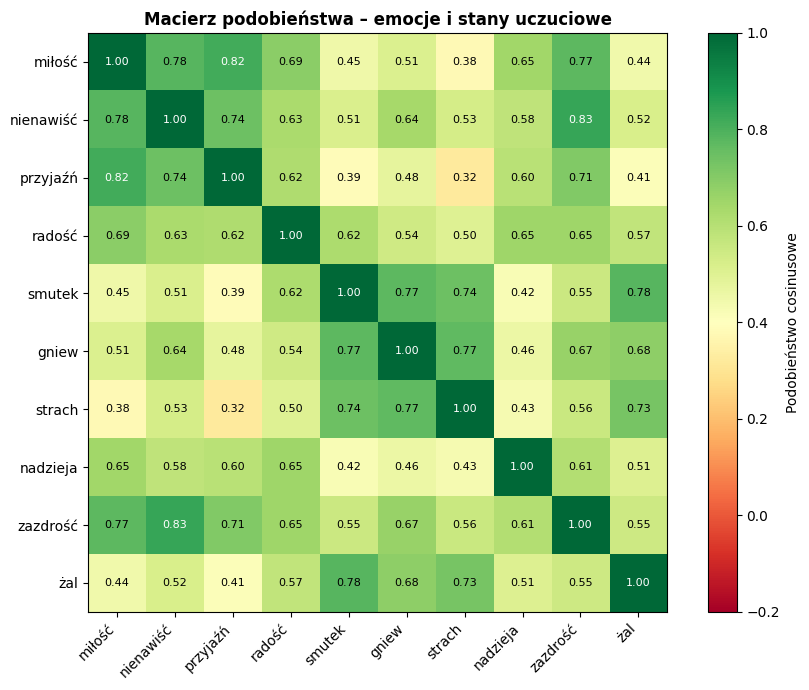

In [14]:
slowa_grupa = ["miłość", "nienawiść", "przyjaźń", "radość", "smutek",
               "gniew", "strach", "nadzieja", "zazdrość", "żal"]

dostepne = [w for w in slowa_grupa if w in wv]
n = len(dostepne)
macierz = np.zeros((n, n))

for i, w1 in enumerate(dostepne):
    for j, w2 in enumerate(dostepne):
        macierz[i][j] = wv.similarity(w1, w2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(macierz, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(dostepne, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(dostepne, fontsize=10)

for i in range(n):
    for j in range(n):
        val = macierz[i][j]
        kolor = 'black' if 0.2 < val < 0.8 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=kolor)

plt.colorbar(im, ax=ax, label='Podobieństwo cosinusowe')
ax.set_title('Macierz podobieństwa – emocje i stany uczuciowe', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()